# Seasonal Agriculture Performance Analysis
## AICTE Major Project
**Student:** Mohammed Sulaiman adnan

**College:** Mahaveer Institute of Science & Technology

This notebook explores the dataset to investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, and relationships.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare data
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df_clean = df.dropna().copy()
print("Dataset cleaned. Shape:", df_clean.shape)

Dataset cleaned. Shape: (3880, 28)


   * Once your Drive is mounted, you can load the CSV file using its path in your Drive. For example, if your file is in a folder named `Colab Notebooks` on your Drive, you would use:

   ```python
   df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/seasonal_agriculture_performance_dataset.csv')
   ```

After successfully uploading or linking the file, rerun the cell that caused the `FileNotFoundError`.

### 1. Profitability Across Seasons

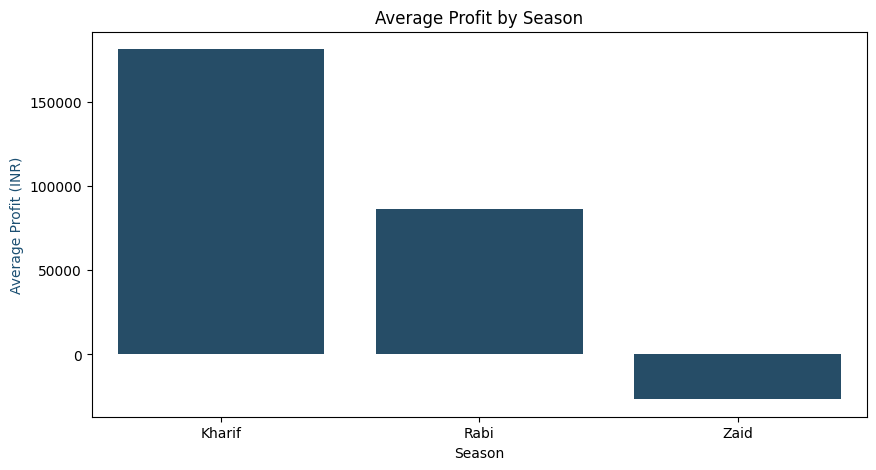

In [44]:
season_stats = df_clean.groupby('Season').agg(
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Water=('Water_Used_m3', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=season_stats, x='Season', y='Avg_Profit', color='#1B4F72', ax=ax1)
ax1.set_ylabel('Average Profit (INR)', color='#1B4F72')
plt.title('Average Profit by Season')
plt.show()

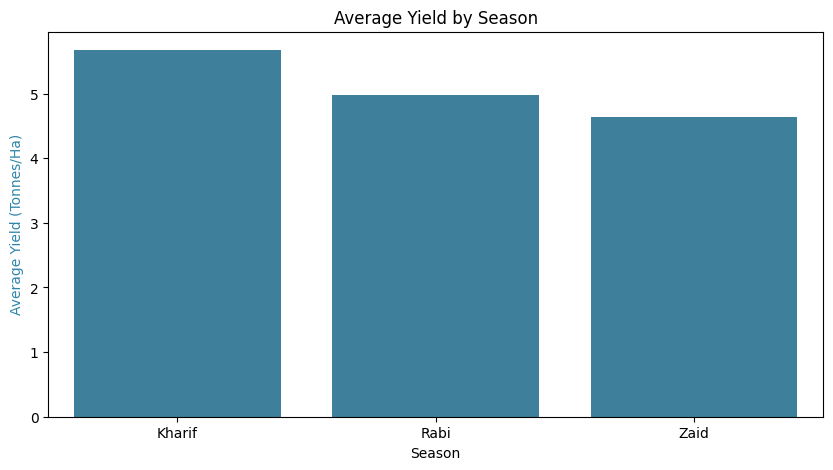

In [45]:
fig, ax2 = plt.subplots(figsize=(10, 5))
sns.barplot(data=season_stats, x='Season', y='Avg_Yield', color='#2E86AB', ax=ax2)
ax2.set_ylabel('Average Yield (Tonnes/Ha)', color='#2E86AB')
plt.title('Average Yield by Season')
plt.show()

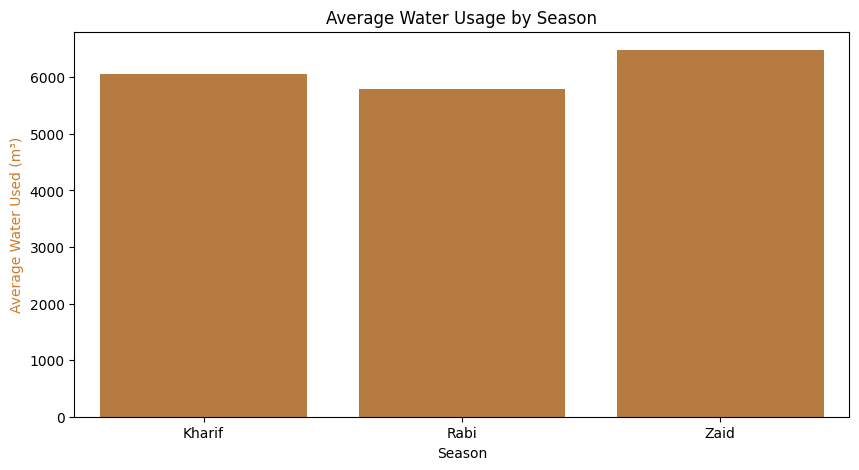

In [46]:
fig, ax3 = plt.subplots(figsize=(10, 5))
sns.barplot(data=season_stats, x='Season', y='Avg_Water', color='#C97B2E', ax=ax3)
ax3.set_ylabel('Average Water Used (m³)', color='#C97B2E')
plt.title('Average Water Usage by Season')
plt.show()

### 5. Input Usage Analysis (Pesticides and Fertilizers)

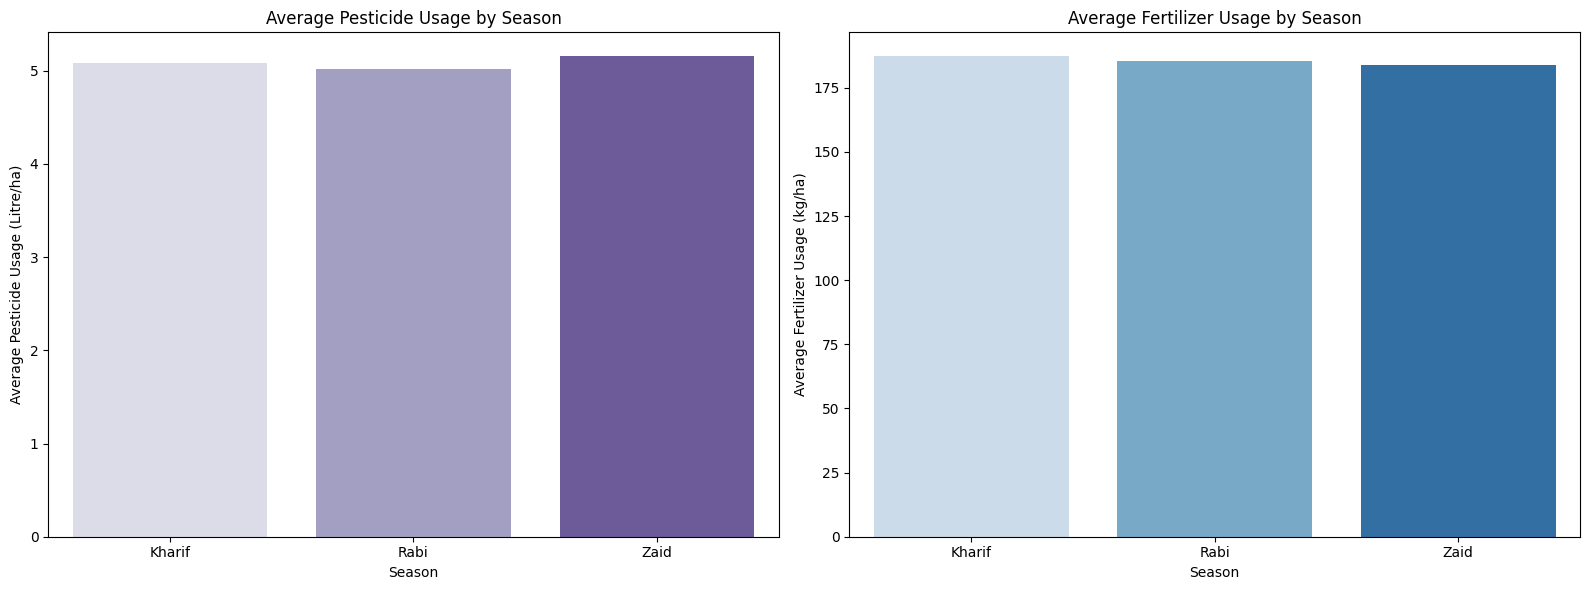

In [47]:
input_stats = df_clean.groupby('Season').agg(
    Avg_Pesticide=('Pesticide_Litre_ha', 'mean'),
    Avg_Fertilizer=('Fertilizer_kg_ha', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=input_stats, x='Season', y='Avg_Pesticide', palette='Purples', ax=axes[0], hue='Season', legend=False)
axes[0].set_title('Average Pesticide Usage by Season')
axes[0].set_ylabel('Average Pesticide Usage (Litre/ha)')

sns.barplot(data=input_stats, x='Season', y='Avg_Fertilizer', palette='Blues', ax=axes[1], hue='Season', legend=False)
axes[1].set_title('Average Fertilizer Usage by Season')
axes[1].set_ylabel('Average Fertilizer Usage (kg/ha)')

plt.tight_layout()
plt.show()

### 2. Resource Intensity Analysis

/tmp/ipykernel_1042/1931677904.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Water_Used_m3', palette='crest')


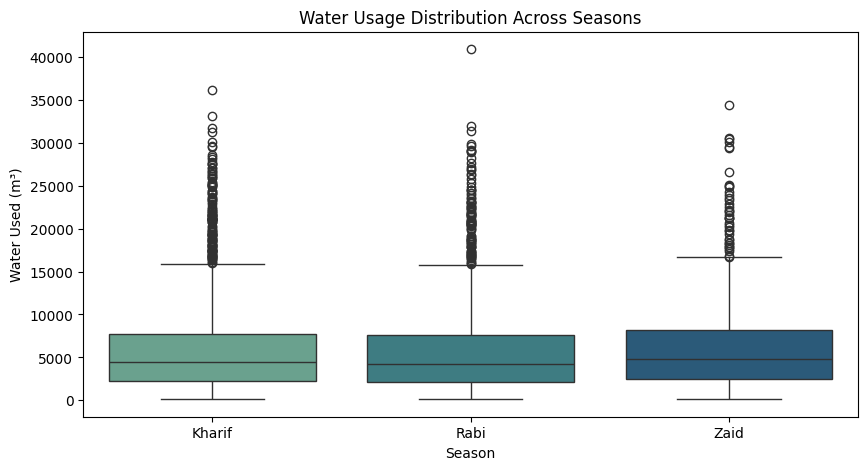

In [48]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='Season', y='Water_Used_m3', palette='crest')
plt.title('Water Usage Distribution Across Seasons')
plt.ylabel('Water Used (m³)')
plt.show()

### 3. Crop-Specific Performance

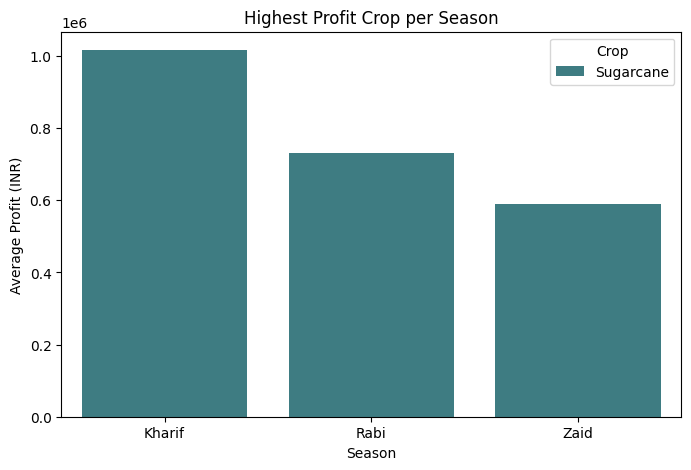

In [49]:
crop_season = df_clean.groupby(['Season', 'Crop'])['Profit_INR'].mean().reset_index()
top_crops = crop_season.loc[crop_season.groupby('Season')['Profit_INR'].idxmax()]

plt.figure(figsize=(8, 5))
sns.barplot(data=top_crops, x='Season', y='Profit_INR', hue='Crop', palette='crest', dodge=False)
plt.title('Highest Profit Crop per Season')
plt.ylabel('Average Profit (INR)')
plt.show()

### 4. Environmental Risk and Rainfall Correlation

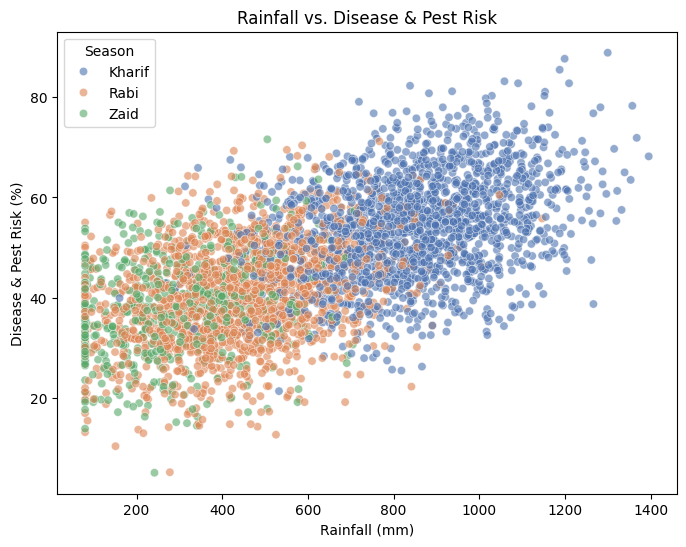

In [50]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='Rainfall_mm', y='Disease_Pest_Risk_pct', hue='Season', alpha=0.6, palette='deep')
plt.title('Rainfall vs. Disease & Pest Risk')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Disease & Pest Risk (%)')
plt.show()

### 6. Water Efficiency vs. Disease/Pest Risk

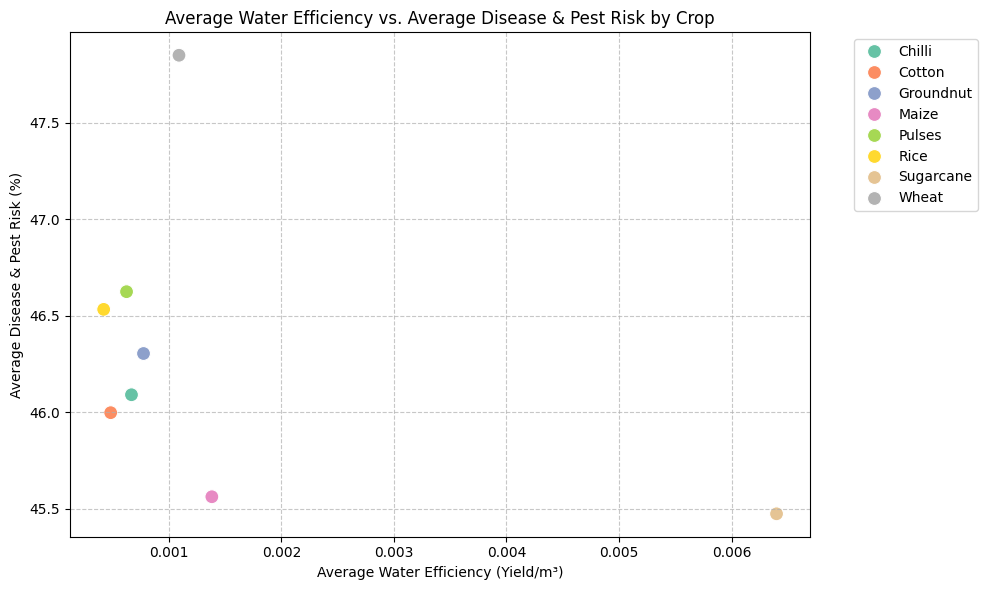

In [51]:
df_clean['Water_Efficiency'] = df_clean['Yield_Tonnes_Ha'] / df_clean['Water_Used_m3']

crop_water_risk = df_clean.groupby('Crop').agg(
    Avg_Water_Efficiency=('Water_Efficiency', 'mean'),
    Avg_Disease_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=crop_water_risk,
    x='Avg_Water_Efficiency',
    y='Avg_Disease_Pest_Risk',
    hue='Crop',
    s=100,  # size of points
    palette='Set2'
)
plt.title('Average Water Efficiency vs. Average Disease & Pest Risk by Crop')
plt.xlabel('Average Water Efficiency (Yield/m³)')
plt.ylabel('Average Disease & Pest Risk (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 7. Correlation Analysis of Key Variables
Exploring how different environmental and input factors correlate with Yield and Profit.

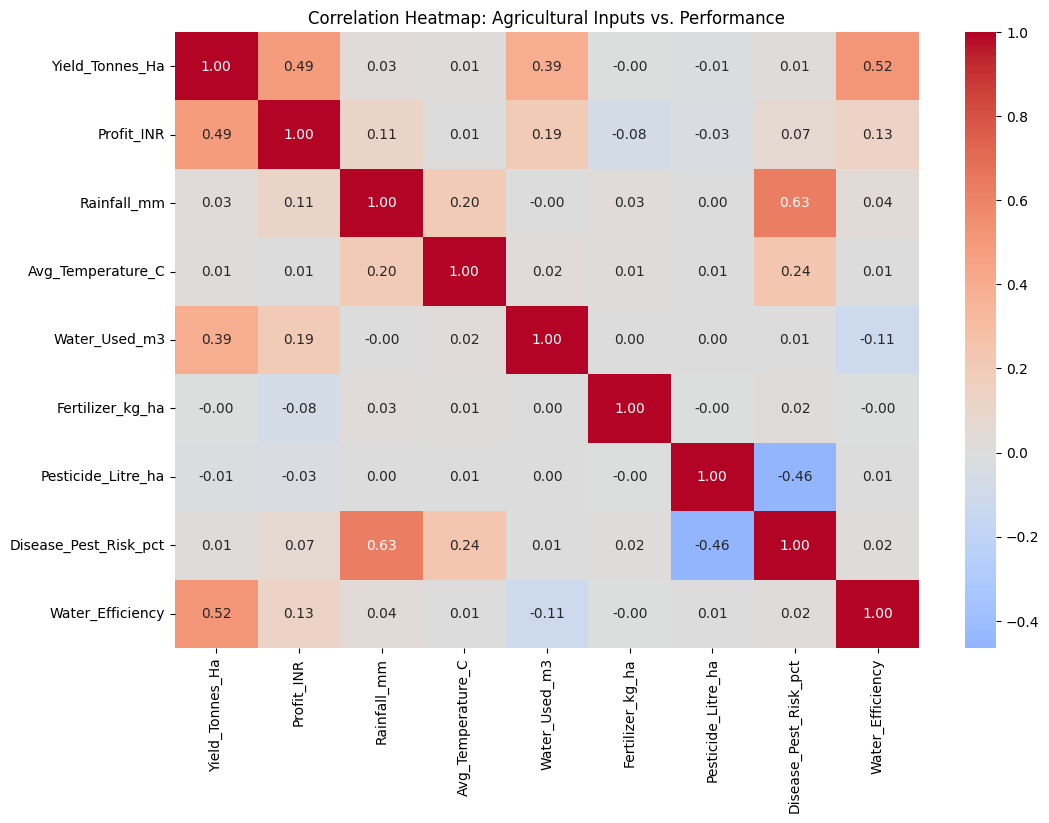

In [52]:
import numpy as np

# Updated with correct column names from the dataset
cols_to_corr = [
    'Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C',
    'Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
    'Disease_Pest_Risk_pct', 'Water_Efficiency'
]

# Filter and calculate correlation
existing_cols = [c for c in cols_to_corr if c in df_clean.columns]
corr_matrix = df_clean[existing_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Agricultural Inputs vs. Performance')
plt.show()

### 8. State-wise Performance Comparison
Analyzing how different states perform in terms of Average Yield and Total Profit.

/tmp/ipykernel_1042/4099992973.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_stats, x='State', y='Avg_Profit', palette='crest')


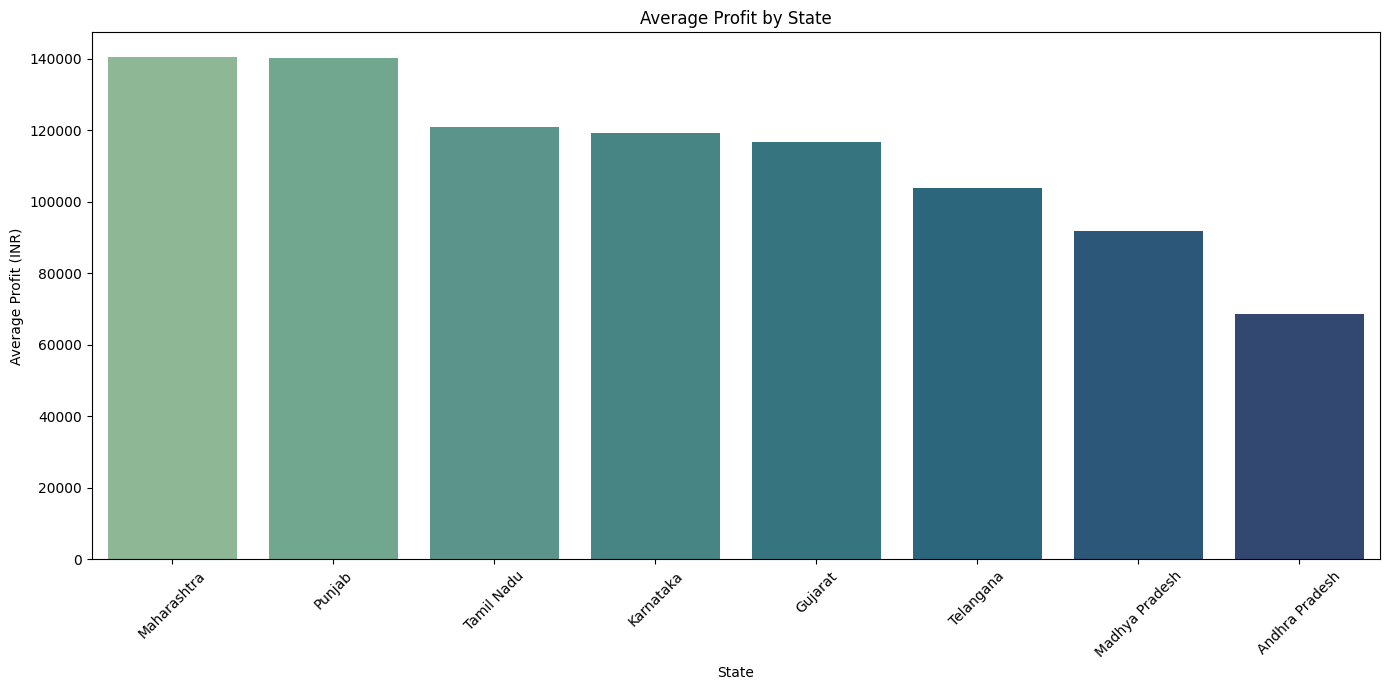

In [53]:
state_stats = df_clean.groupby('State').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).sort_values(by='Avg_Profit', ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=state_stats, x='State', y='Avg_Profit', palette='crest')
plt.xticks(rotation=45)
plt.title('Average Profit by State')
plt.ylabel('Average Profit (INR)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1042/2798079193.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_stats.sort_values(by='Avg_Yield', ascending=False), x='State', y='Avg_Yield', palette='flare')


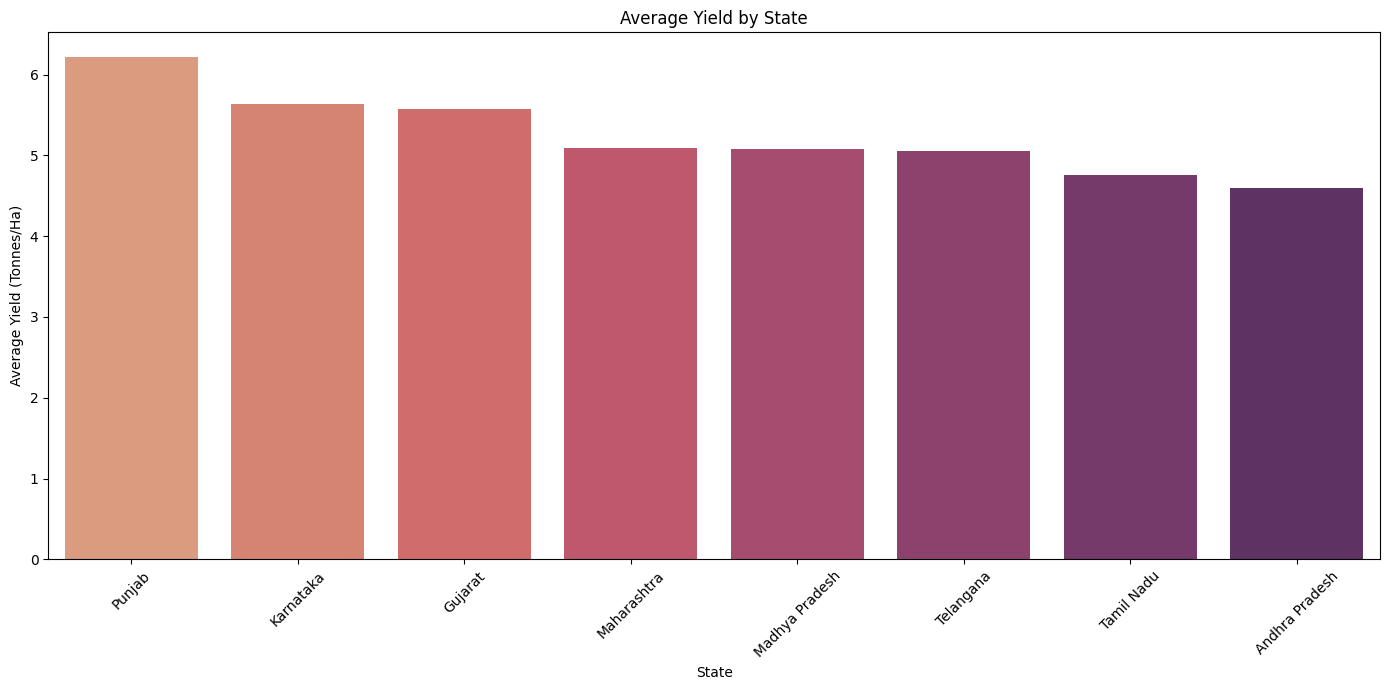

In [54]:
plt.figure(figsize=(14, 7))
sns.barplot(data=state_stats.sort_values(by='Avg_Yield', ascending=False), x='State', y='Avg_Yield', palette='flare')
plt.xticks(rotation=45)
plt.title('Average Yield by State')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

### 10. Environmental Condition Analysis
Visualizing average Rainfall and Temperature across seasons to understand the growing environment.

/tmp/ipykernel_1042/323906807.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1F4E79'` for the same effect.

  sns.barplot(data=env_stats, x='Season', y='Avg_Rainfall', color='#1F4E79', alpha=0.6, ax=ax1, hue='Season', legend=False)


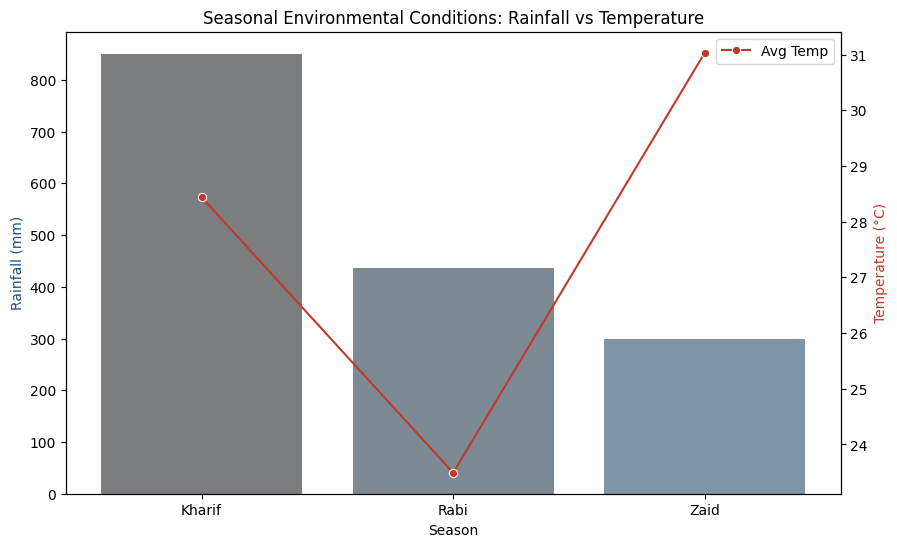

In [55]:
# Using the verified column name 'Avg_Temperature_C'
env_stats = df_clean.groupby('Season').agg(
    Avg_Rainfall=('Rainfall_mm', 'mean'),
    Avg_Temp=('Avg_Temperature_C', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(data=env_stats, x='Season', y='Avg_Rainfall', color='#1F4E79', alpha=0.6, ax=ax1, hue='Season', legend=False)
ax1.set_ylabel('Rainfall (mm)', color='#1F4E79')

ax2 = ax1.twinx()
sns.lineplot(data=env_stats, x='Season', y='Avg_Temp', marker='o', color='#C0392B', ax=ax2, label='Avg Temp')
ax2.set_ylabel('Temperature (°C)', color='#C0392B')

plt.title('Seasonal Environmental Conditions: Rainfall vs Temperature')
plt.show()

### 9. Yield Gap Analysis
Identifying the difference between average performance and maximum potential for each crop.

/tmp/ipykernel_1042/2098882736.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yield_gap, x='Crop', y='Gap', palette='mako')


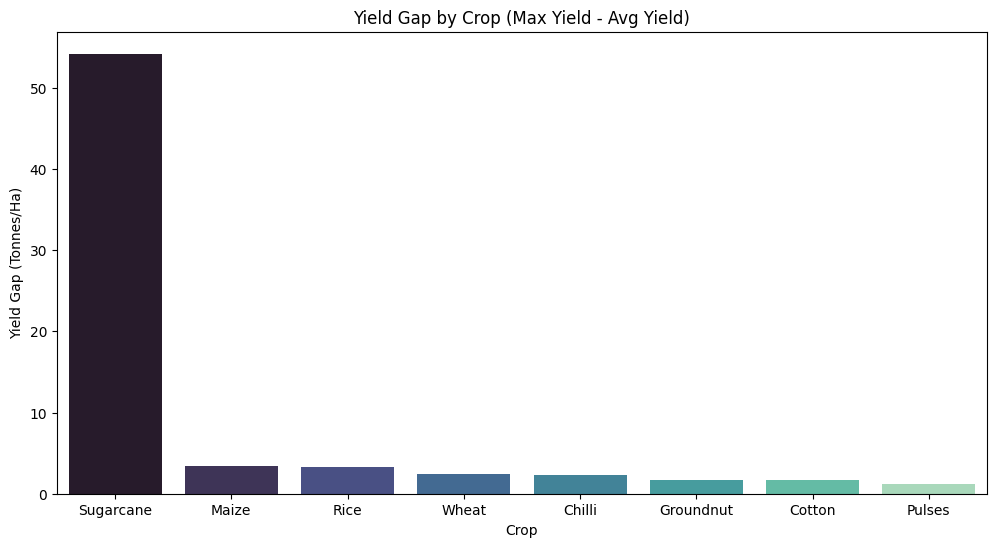

In [56]:
yield_gap = df_clean.groupby('Crop').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Max_Yield=('Yield_Tonnes_Ha', 'max')
).reset_index()

yield_gap['Gap'] = yield_gap['Max_Yield'] - yield_gap['Avg_Yield']
yield_gap = yield_gap.sort_values(by='Gap', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=yield_gap, x='Crop', y='Gap', palette='mako')
plt.title('Yield Gap by Crop (Max Yield - Avg Yield)')
plt.ylabel('Yield Gap (Tonnes/Ha)')
plt.show()